# Fleet Strategy Engine EDA

Use this notebook to inspect the input batch and, after running the CLI, verify the recommendation output.

In [9]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 180)

INPUT_PATH = Path('data/sample_data.csv')
OUTPUT_PATH = Path('outputs/recommendations.csv')
SUMMARY_PATH = Path('outputs/summary.json')

raw = pd.read_csv(INPUT_PATH)
recommendations = pd.read_csv(OUTPUT_PATH) if OUTPUT_PATH.exists() else None

raw.shape, None if recommendations is None else recommendations.shape

((136, 9), (136, 27))

## Input Schema And Quality Checks

In [2]:
raw.head()

,station,segment,fleet_size,utilization_pct,avg_daily_rate,avg_daily_fleet_cost,avg_daily_operating_cost,competitor_rate,market_share_pct
0,ATL,Economy,121,91,43,14,11,58,20.2
1,ATL,SUV,57,91,132,43,14,136,16.5
2,ATL,Minivan,54,86,102,30,14,102,16.1
3,MCO,Economy,120,96,48,16,11,57,17.4
4,MCO,SUV,61,90,107,36,16,121,17.7


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   station                   136 non-null    object 
 1   segment                   136 non-null    object 
 2   fleet_size                136 non-null    int64  
 3   utilization_pct           136 non-null    int64  
 4   avg_daily_rate            136 non-null    int64  
 5   avg_daily_fleet_cost      136 non-null    int64  
 6   avg_daily_operating_cost  136 non-null    int64  
 7   competitor_rate           136 non-null    int64  
 8   market_share_pct          136 non-null    float64
dtypes: float64(1), int64(6), object(2)
memory usage: 9.7+ KB


In [4]:
quality_checks = {
    'row_count': len(raw),
    'station_count': raw['station'].nunique(),
    'segment_count': raw['segment'].nunique(),
    'blank_cells': int(raw.isna().sum().sum()),
    'duplicate_station_segment_rows': int(raw.duplicated(['station', 'segment']).sum()),
    'invalid_utilization_rows': int(((raw['utilization_pct'] < 0) | (raw['utilization_pct'] > 100)).sum()),
    'invalid_market_share_rows': int(((raw['market_share_pct'] < 0) | (raw['market_share_pct'] > 100)).sum()),
    'non_positive_fleet_rows': int((raw['fleet_size'] <= 0).sum()),
    'non_positive_competitor_rate_rows': int((raw['competitor_rate'] <= 0).sum()),
}
quality_checks

{'row_count': 136,
 'station_count': 50,
 'segment_count': 5,
 'blank_cells': 0,
 'duplicate_station_segment_rows': 0,
 'invalid_utilization_rows': 0,
 'invalid_market_share_rows': 0,
 'non_positive_fleet_rows': 0,
 'non_positive_competitor_rate_rows': 0}

## Input Distributions

In [5]:
raw.describe(include='all')

,station,segment,fleet_size,utilization_pct,avg_daily_rate,avg_daily_fleet_cost,avg_daily_operating_cost,competitor_rate,market_share_pct
count,136,136,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000
unique,50,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,MIA,Economy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,46.705882,82.242647,98.830882,35.227941,16.102941,103.117647,11.293382
std,NaN,NaN,27.508414,8.282508,45.211365,24.577004,4.372099,46.281115,4.468013
min,NaN,NaN,8.000000,59.000000,40.000000,13.000000,10.000000,40.000000,3.500000
25%,NaN,NaN,25.000000,74.000000,53.000000,17.750000,13.000000,58.000000,7.875000
50%,NaN,NaN,40.500000,84.000000,102.000000,33.000000,16.000000,106.000000,11.100000
75%,NaN,NaN,61.250000,88.000000,127.000000,42.000000,18.250000,133.250000,13.775000


In [6]:
raw.groupby('segment').agg(
    rows=('segment', 'size'),
    avg_fleet_size=('fleet_size', 'mean'),
    avg_utilization=('utilization_pct', 'mean'),
    avg_rate=('avg_daily_rate', 'mean'),
    avg_competitor_rate=('competitor_rate', 'mean'),
    avg_market_share=('market_share_pct', 'mean'),
).round(2).sort_values('rows', ascending=False)

,rows,avg_fleet_size,avg_utilization,avg_rate,avg_competitor_rate,avg_market_share
segment,,,,,,
Economy,50,73.24,82.46,49.72,53.04,11.22
SUV,50,37.46,86.20,115.94,121.72,11.98
Truck,15,18.80,77.27,131.13,133.67,9.84
Premium,11,15.82,67.73,199.91,205.45,7.38
Minivan,10,36.10,84.80,99.20,102.10,14.72


In [12]:
raw.groupby('station').agg(
    rows=('segment', 'size'),
    avg_fleet_size=('fleet_size', 'mean'),
    avg_utilization=('utilization_pct', 'mean'),
    avg_rate=('avg_daily_rate', 'mean'),
    avg_competitor_rate=('competitor_rate', 'mean'),
    avg_market_share=('market_share_pct', 'mean'),
).round(2).sort_values('rows', ascending=False)

,rows,avg_fleet_size,avg_utilization,avg_rate,avg_competitor_rate,avg_market_share
station,,,,,,
LAX,4,50.50,82.75,114.75,117.50,9.88
MIA,4,49.75,85.25,111.75,119.00,13.82
ANC,3,28.33,88.33,98.67,101.33,11.60
JFK,3,52.67,80.67,130.33,141.00,10.30
LGA,3,41.33,83.33,118.00,127.67,10.13
MCI,3,38.67,79.33,107.67,111.67,10.53
ATL,3,77.33,89.33,92.33,98.67,17.60
MEM,3,24.67,72.33,104.00,103.33,4.90
MSY,3,46.00,88.00,90.00,92.00,17.87


Matplotlib is building the font cache; this may take a moment.


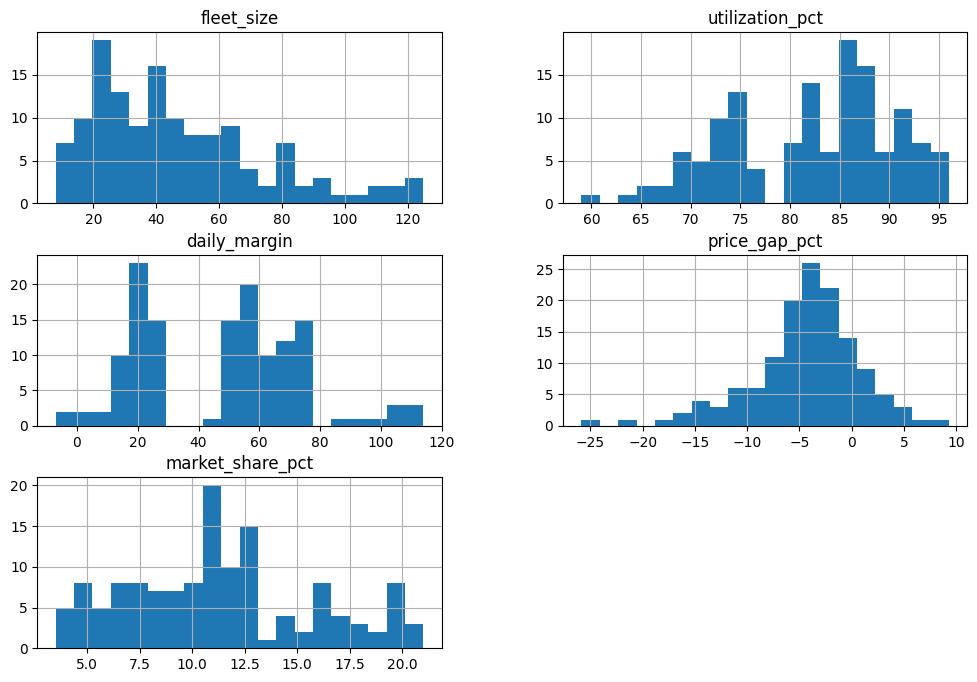

In [11]:
input_scan = raw.assign(
    daily_margin=lambda df: df['avg_daily_rate'] - df['avg_daily_fleet_cost'] - df['avg_daily_operating_cost'],
    price_gap_pct=lambda df: (df['avg_daily_rate'] - df['competitor_rate']) / df['competitor_rate'] * 100,
)

input_scan[['fleet_size', 'utilization_pct', 'daily_margin', 'price_gap_pct', 'market_share_pct']].hist(figsize=(12, 8), bins=20);

## Useful Pre-Recommendation Queries

In [ ]:
# Capacity-constrained rows where demand may exceed available fleet.
input_scan.query('utilization_pct >= 90').sort_values(['utilization_pct', 'daily_margin'], ascending=False).head(20)

In [ ]:
# Potential overfleet rows.
input_scan.query('utilization_pct < 75').sort_values(['utilization_pct', 'market_share_pct']).head(20)

In [ ]:
# High utilization that may be driven by discounting versus competitor.
input_scan.query('utilization_pct >= 90 and price_gap_pct <= -10').sort_values('price_gap_pct').head(20)

In [ ]:
# Margin risk rows.
input_scan.query('daily_margin <= 0').sort_values('daily_margin')

## Recommendation Output Checks

Run the CLI first if `recommendations` is `None`:

```bash
uv run python main.py --input data/sample_data.csv --output outputs/recommendations.csv --summary-output outputs/summary.json
```

In [10]:
if recommendations is None:
    print('No output file found yet. Run the CLI command above, then restart or rerun the first cell.')
else:
    display(recommendations.head())

,station,segment,fleet_size,utilization_pct,avg_daily_rate,avg_daily_fleet_cost,avg_daily_operating_cost,competitor_rate,market_share_pct,daily_margin,price_gap,price_gap_pct,estimated_rented_cars,target_fleet_at_85_util,recommended_fleet_delta,utilization_band,margin_band,pricing_signal,market_share_signal,recommendation,confidence,pricing_action,buy_score,reduce_score,reason_codes,pricing_reason_codes,reasoning
0,ATL,Economy,121,91,43,14,11,58,20.2,18,-15,-25.862069,110.11,130,9,capacity_constrained,healthy_margin,high_utilization_but_discounted_vs_competitor,strong_share,BUY,high,RAISE_PRICE_TEST,4,0,utilization_above_90|healthy_margin|strong_share_and_high_utilization|discounted_vs_competitor_with_high_utilization,price_below_competitor_high_utilization_positive_margin|strong_share_supports_pricing_power,"BUY: Utilization is 91.0%, above the capacity threshold, and daily margin is $18.00. Market share is 20.2%, supporting the demand signal. Recommend adding about 9 vehicles. Bec..."
1,ATL,SUV,57,91,132,43,14,136,16.5,75,-4,-2.941176,51.87,62,5,capacity_constrained,strong_margin,near_competitor_price,strong_share,BUY,high,MONITOR_PRICE,6,0,utilization_above_90|strong_margin|strong_share_and_high_utilization|pricing_near_competitor,pricing_signal_balanced,"BUY: Utilization is 91.0%, above the capacity threshold, and daily margin is $75.00. Market share is 16.5%, supporting the demand signal. Recommend adding about 5 vehicles. Pri..."
2,ATL,Minivan,54,86,102,30,14,102,16.1,58,0,0.000000,46.44,55,0,target_range,strong_margin,near_competitor_price,strong_share,HOLD,medium,MONITOR_PRICE,2,0,utilization_in_target_range|strong_margin|strong_market_share|pricing_near_competitor,pricing_signal_balanced,"HOLD: Utilization is 86.0% and daily margin is $58.00. Signals are balanced, so keeping the current fleet is the lowest-risk action. Pricing guidance: monitor price because pri..."
3,MCO,Economy,120,96,48,16,11,57,17.4,21,-9,-15.789474,115.20,136,16,capacity_constrained,healthy_margin,high_utilization_but_discounted_vs_competitor,strong_share,BUY,high,RAISE_PRICE_TEST,4,0,utilization_above_90|healthy_margin|strong_share_and_high_utilization|discounted_vs_competitor_with_high_utilization,price_below_competitor_high_utilization_positive_margin|strong_share_supports_pricing_power,"BUY: Utilization is 96.0%, above the capacity threshold, and daily margin is $21.00. Market share is 17.4%, supporting the demand signal. Recommend adding about 16 vehicles. Be..."
4,MCO,SUV,61,90,107,36,16,121,17.7,55,-14,-11.570248,54.90,65,4,capacity_constrained,strong_margin,high_utilization_but_discounted_vs_competitor,strong_share,BUY,high,RAISE_PRICE_TEST,5,0,utilization_above_90|strong_margin|strong_share_and_high_utilization|discounted_vs_competitor_with_high_utilization,price_below_competitor_high_utilization_positive_margin|strong_share_supports_pricing_power,"BUY: Utilization is 90.0%, above the capacity threshold, and daily margin is $55.00. Market share is 17.7%, supporting the demand signal. Recommend adding about 4 vehicles. Bec..."


In [ ]:
if recommendations is not None:
    display(recommendations['recommendation'].value_counts().reindex(['BUY', 'HOLD', 'REDUCE'], fill_value=0))
    display(pd.crosstab(recommendations['segment'], recommendations['recommendation']))

In [ ]:
if recommendations is not None:
    display(recommendations.groupby('recommendation').agg(
        rows=('recommendation', 'size'),
        avg_utilization=('utilization_pct', 'mean'),
        avg_margin=('daily_margin', 'mean'),
        avg_market_share=('market_share_pct', 'mean'),
        net_delta=('recommended_fleet_delta', 'sum'),
    ).round(2))

## Recommendation Verification Queries

In [ ]:
# BUY candidates ranked by recommended fleet increase.
if recommendations is not None:
    display(recommendations.query("recommendation == 'BUY'").sort_values(['recommended_fleet_delta', 'utilization_pct'], ascending=False).head(20))

In [ ]:
# REDUCE candidates ranked by recommended reduction.
if recommendations is not None:
    display(recommendations.query("recommendation == 'REDUCE'").sort_values(['recommended_fleet_delta', 'utilization_pct']).head(20))

In [ ]:
# Rows where utilization is high but recommendation is not BUY. Useful for checking conflict logic.
if recommendations is not None:
    display(recommendations.query("utilization_pct >= 90 and recommendation != 'BUY'").sort_values('utilization_pct', ascending=False))

In [ ]:
# Rows where utilization is low but recommendation is not REDUCE. Useful for checking offsetting positive signals.
if recommendations is not None:
    display(recommendations.query("utilization_pct < 75 and recommendation != 'REDUCE'").sort_values('utilization_pct'))

In [ ]:
# Verify non-positive margin never receives BUY.
if recommendations is not None:
    display(recommendations.query("daily_margin <= 0"))

In [ ]:
# Station-level net fleet movement for planning review.
if recommendations is not None:
    display(recommendations.groupby('station').agg(
        net_delta=('recommended_fleet_delta', 'sum'),
        buy_rows=('recommendation', lambda s: (s == 'BUY').sum()),
        reduce_rows=('recommendation', lambda s: (s == 'REDUCE').sum()),
        avg_utilization=('utilization_pct', 'mean'),
        avg_margin=('daily_margin', 'mean'),
    ).round(2).sort_values('net_delta', ascending=False).head(25))